# LAB 4
### Beverley Appiatse

## Q1.

OK, a warm-up, just to get started.

1. Set up a grid of K equally spaced values between 0 and 1, {1/K, 2/K, ..., K/K}.
2. Draw a point from the grid at random with equal probability.
3. For a very small K, repeat the above process n = 5_000 times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase K?

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

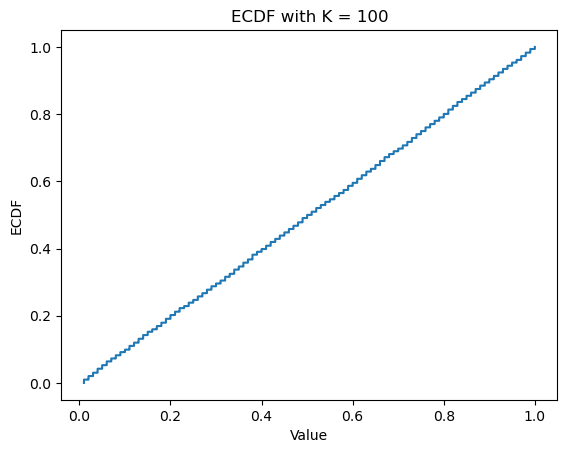

In [20]:
K = 100
n = 5000

grid = np.arange(1, K + 1) / K
draws = np.random.choice(grid, size=n)
ecdf = ECDF(draws)

plt.step(ecdf.x, ecdf.y)
plt.xlabel("Value")
plt.ylabel("ECDF")
plt.title(f"ECDF with K = 100")
plt.show()

As you increase K, this approaches a uniform distribution.

## Q2.

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw n = 32 values from Uniform[-sqrt(3), sqrt(3)]; these are your data. The choice of 
±3 ± 3 ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by np.sqrt(n). 
3. Repeat the above process b = 5_000 times and plot the ECDF.
4. What distribution does this approach as n increases?

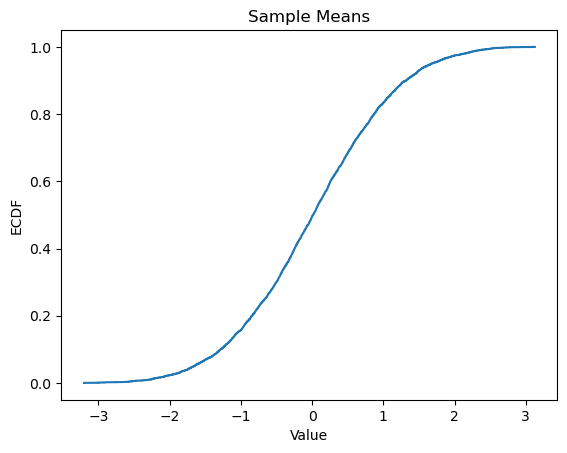

In [17]:
n = 32
b = 5000
results = []

for i in range(b):
    sample = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=n)
    sample_mean = np.mean(sample)
    results.append(sample_mean * np.sqrt(n))

ecdf = ECDF(results)

plt.step(ecdf.x, ecdf.y)
plt.xlabel("Value")
plt.ylabel("ECDF")
plt.title("Sample Means")
plt.show()

Because of CLT, the distribution approaches a standard normal distribution as n increases.

## Q3
In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability p, and we want to study the distribution of the survivors.

1. Flip n = 40 coins, which each come up heads with probability p=1/2 and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, n * p.
3. Divide by the standard deviation sqrt( n * p * (1-p) ).
4. Repeat the above process b = 5_000 times and plot the ECDF.
5. What distribution does this approach as n increases?
6. How do the results change as you adjust p?


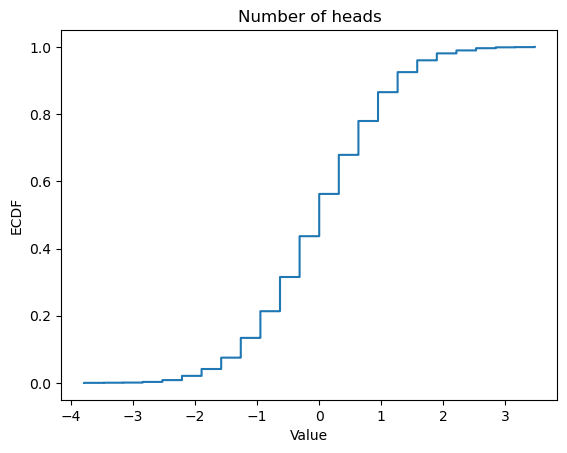

In [18]:
n = 40 
p = 0.5
b = 5000
results = []

for i in range (b):
    heads = np.random.binomial(n,p)
    standardized = (heads - n * p) / np.sqrt(n * p * (1 - p))
    results.append(standardized)

ecdf = ECDF(results)

plt.step(ecdf.x, ecdf.y)
plt.xlabel("Value")
plt.ylabel("ECDF")
plt.title("Number of heads")
plt.show()

As n increases, this distribution approaches a standard normal distribution. Changing p to be closer to 0 or 1 would make teh distribution to be less normal

## Q4.

A process is running in discrete time. In each time interval of length dt, it terminates with probability r * dt, where r * dt < 1. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by dt.
3. Repeat the simulation n = 5_000 times and plot the ECDF, for a value of dt close to zero (e.g. dt = 1e-3).
4. What distribution does this approach as dt goes to zero?
5. How do the results change as you adjust r?

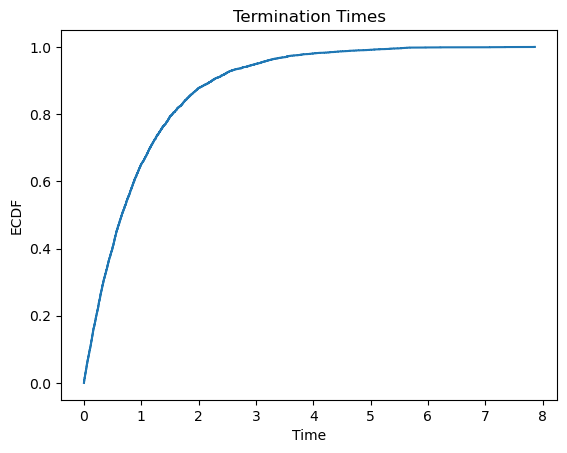

In [19]:
dt = 1e-3
r = 1
n = 5000

times = []

for i in range(n):
    periods = 0
    while np.random.random() >= r * dt:
        periods += 1
    times.append(periods * dt)
    
ecdf = ECDF(times)

plt.step(ecdf.x, ecdf.y)
plt.xlabel("Time")
plt.ylabel("ECDF")
plt.title("Termination Times")
plt.show()

As dt approaches 0, the termination times approaches an exponential distribution. This means that increasing r would result in a faster termination

I used gen AI to hel pme troubleshoot my code.